### Value at Risk
Value at Risk represent the amout of portfolio that could be lost with a certain confidence level due to random stock price movements in a given period of time

We can investigate VaR for an asset with a time window of one year

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

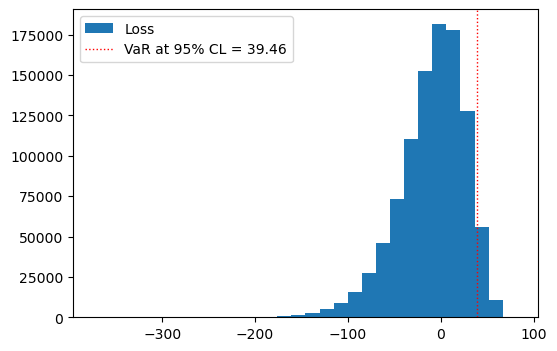

In [5]:
m = 0.12
sigma = 0.3
r = 0.08
S0 = 100
t = 1

S_risk_free = S0 * np.exp(r * t)

# Samples from distribution of stock price at t
mean_kt = m * t 
var_kt  = sigma**2 * t
St = S0 * np.exp(np.random.normal(loc=mean_kt, scale=np.sqrt(var_kt), size=1000000))

# Theoretical pdf of stock price distribution at t
mean_St = S0 * np.exp(m * t + 0.5 * sigma**2 * t)
var_St  = (S0 * np.exp(m * t + 0.5 * sigma**2 * t))**2 * (np.exp(sigma**2 * t) - 1)
Ss = np.linspace(0, 400, 2500)
log_mean = np.log(mean_St)
log_std = np.sqrt(var_kt)
lognorm = scipy.stats.lognorm.pdf(Ss, s=log_std, loc=0, scale=np.exp(log_mean))

# Define loss
Loss = S_risk_free - St
VaR  = np.percentile(Loss, 95) 

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(Loss, bins=30, label='Loss')
ax.axvline(VaR, lw=1, ls=':', color='red', label=f'VaR at 95% CL = {round(VaR, 2)}')
ax.legend()
plt.show()

Let's now consider the investment of $1,000 in European call options on a stock with current price `S(0) = 60` dollars

The options expire after `6 months` with strike price `K = 40` dollars

Assume `σ = 30%`, `r = 8%`, and the expected `logarithmic return on stock is 12%`

1. Compute VaR after 6 months at 95% confidence level
2. Find the final wealth if the stock price grows at the expected rate
3. Find the stock price level that will be exceeded with 5% probability and compute the corresponding final payoff.

The stock price follows a Geometric Brownian Motion (GBM) such that $$dS_t = \mu S_t dt + \sigma S_t dW_t$$
Since we are considering the log-return we have $$d log(S_t) = (\mu - \frac{\sigma^2}{2})dt + \sigma dW_t$$
leading to 
$$
\begin{align}
S_t &= S_0 e^{(\mu - \frac{\sigma^2}{2})t + \sigma W_t} \\
E[S_t] &= S_0 e^{\mu t} \\
Var(S_t) &= (S_0 e^{\mu t})^2 (e^{\sigma^2 t} - 1)
\end{align}
$$

In terms of stock price: 
$$
\begin{align}
S_t &= S_0 e^{(\mu - \frac{\sigma^2}{2})t + \sigma W_t} \\
log(S_t) &= log(S_0) + (\mu - \frac{\sigma^2}{2})t + \sigma W_t \\
W_t &\sim N(0, t) \\
\sigma W_t &\sim N(0, \sigma^2 t) \\ 
log(S_t) &\sim N\left( log(S_0) + (\mu - \frac{\sigma^2}{2})t, \sigma^2 t \right) \\ 
S_t &\sim Lognormal\left( log(S_0) + (\mu - \frac{\sigma^2}{2})t, \sigma^2 t \right)
\end{align}
$$

In terms of log-return:
$$
\begin{align}
k &= log\left( \frac{S_t}{S_0} \right) = (\mu - \frac{\sigma^2}{2})t + \sigma W_t \\
W_t &\sim N(0, t) \\
\sigma W_t &\sim N(0, \sigma^2 t) \\ 
k &\sim N\left( (\mu - \frac{\sigma^2}{2})t, \sigma^2 t \right)
\end{align}
$$

In [94]:
investment = 1000
S0 = 60
K = 40
r = 0.08
sigma = 0.3
m = 0.12 # this is the expected log-return = (mu - 0.5 sigma^2)

confidence_level = 0.95
nSims = 1_000_000
nSteps = 126 # 6 months of trading days in a year

# Time settings
# The time window of interest is 6 months, in trading days this is 126
t = 0.5
dt = t / nSteps

In [95]:
# Call option cost at present time
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2 ) * t) / sigma / np.sqrt(t)
d2 = d1 - sigma * np.sqrt(t)
Ce0 = S0 * scipy.stats.norm.cdf(d1) - K * np.exp(-r * t) * scipy.stats.norm.cdf(d2)

# Number of call options in investment
nOptions = investment / Ce0

# Simulate log-return increments
log_returns = np.random.normal(
    loc=m * dt,
    scale=sigma * np.sqrt(dt),
    size=(nSims, nSteps)
)

# Cumulative log-return path
cum_log_returns = np.cumsum(log_returns, axis=1)

# GBM stock paths
S_values = S0 * np.exp(cum_log_returns)

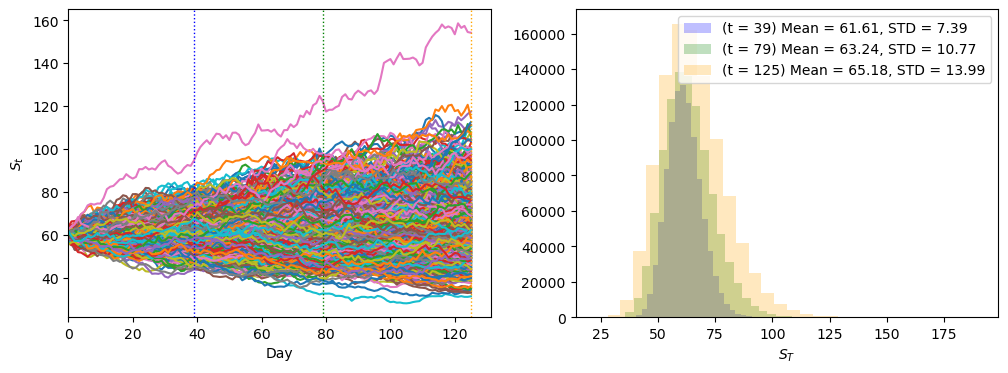

In [96]:
# Timestamps for plotting
times = [39, 79, 125]
colors = ['blue', 'green', 'orange']

fig, ax = plt.subplots(1, 2, figsize=(12,4))
for i in range(1000):
    ax[0].plot(S_values[i,:])

for i in range(len(times)):
    ax[0].axvline(times[i], lw=1, ls=':', color=colors[i])
    ax[1].hist(S_values[:, times[i]], bins=30, color=colors[i], alpha=0.25, 
               label=f'(t = {times[i]}) Mean = {round(np.mean(S_values[:, times[i]]), 2)}, STD = {round(np.std(S_values[:, times[i]]), 2)}')

ax[0].set_xlabel('Day')
ax[0].set_ylabel(r'$S_t$')
ax[0].set_xlim(0, )

ax[1].set_xlabel(r'$S_T$')
ax[1].legend()

plt.show()

In [97]:
# Final option portfolio payoff distribution
final_payoff = nOptions * np.maximum(S_values[:, -1] - K, 0)

# Loss relative to risk-free $1000 investment
loss = investment * np.exp(r * t) - final_payoff

# 95% VaR is the 95th percentile of loss
VaR_95 = np.quantile(loss, 0.95)

# Equivalent method: initial investment minus 5th percentile final payoff
payoff_5pct = np.quantile(final_payoff, 0.05)
VaR_95_equivalent = investment - payoff_5pct

# Stock price at 5th percentile
S_5pct = np.quantile(S_values[:, -1], 0.05)

# Stock price exceeded with only 5% probability, i.e. 95th percentile
S_95pct = np.quantile(S_values[:, -1], 0.95)

# Final stock price if log-price grows at expected log-return m
S_expected_log_growth = S0 * np.exp(m * t)
payoff_expected_log_growth = nOptions * max(S_expected_log_growth - K, 0)

print(f"Call price today: ${Ce0:.2f}")
print(f"Number of calls bought: {nOptions:.4f}")

print(f"\nExpected log-growth stock price: ${S_expected_log_growth:.2f}")
print(f"Payoff at expected log-growth stock price: ${payoff_expected_log_growth:.2f}")

print(f"\n5th percentile final stock price: ${S_5pct:.2f}")
print(f"5th percentile final payoff: ${payoff_5pct:.2f}")

print(f"\n95% VaR from loss simulation: ${VaR_95:.2f}")
print(f"95% VaR from payoff percentile: ${VaR_95_equivalent:.2f}")

print(f"\n95th percentile stock price: ${S_95pct:.2f}")

Call price today: $21.63
Number of calls bought: 46.2235

Expected log-growth stock price: $63.71
Payoff at expected log-growth stock price: $1095.97

5th percentile final stock price: $44.94
5th percentile final payoff: $228.32

95% VaR from loss simulation: $812.50
95% VaR from payoff percentile: $771.68

95th percentile stock price: $90.33
